In [1]:
import sys
from pathlib import Path

# Add project root to Python path
project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))

/home/gmurp/miniconda3/envs/d200proj/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Post-LASSO trained
Best Lasso Params: 0.001
Random Forest trained
Best RF Params: {'n_estimators': 500, 'max_depth': 20}
Neural Network trained
Best NN Params: {'architecture': [64, 32, 16], 'learning_rate': 0.01}
Ensemble weights:
Post-Lasso: 0.2279
Random Forest: 0.4278
Neural Network: 0.3660
Ensemble MSE (test): 0.0070
Ensemble R² (test): 0.6863
Meta-Learner Ensemble trained
Ensemble weights:
Post-Lasso: 0.2263
Random Forest: 0.4380
Neural Network: 0.3654
MSE: 0.0070, R²: 0.6857

Individual model test metrics:
Post-Lasso - MSE: 0.0098, R²: 0.5597
Random Forest - MSE: 0.0085, R²: 0.6214
Neural Network - MSE: 0.0099, R²: 0.5575
Actual vs Predicted plots saved as PDF for LaTeX.


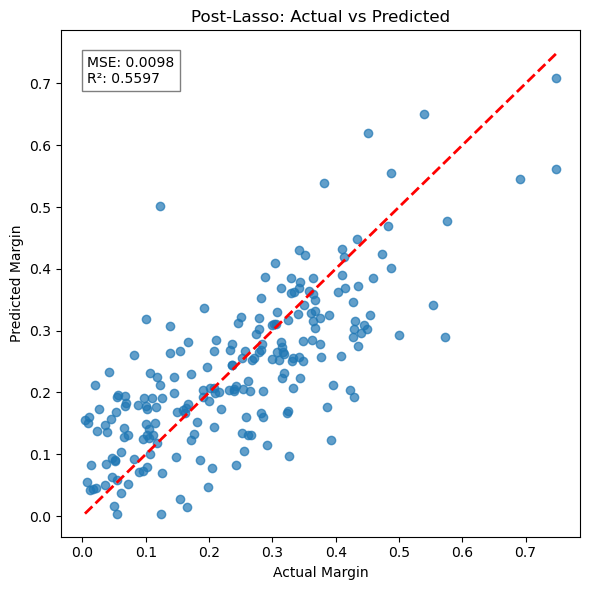

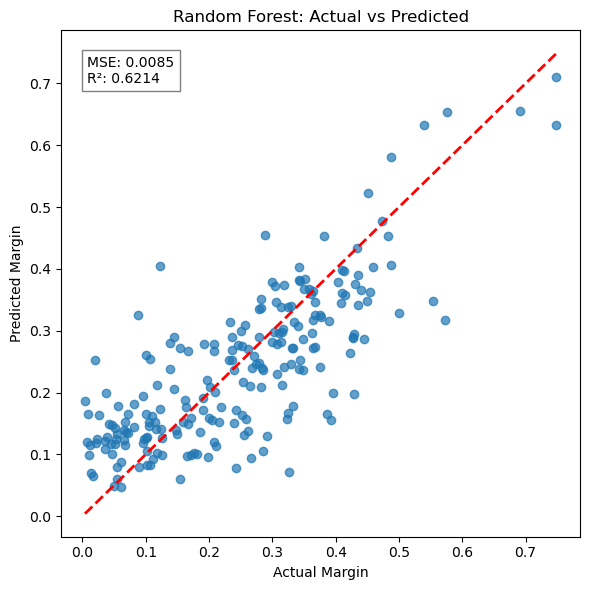

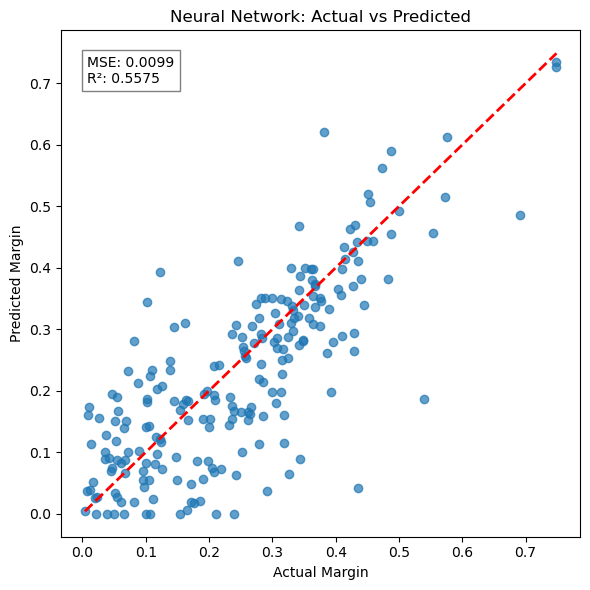

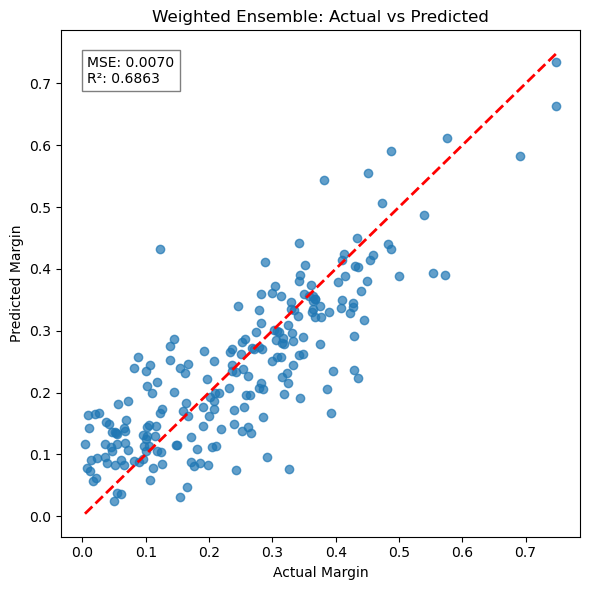

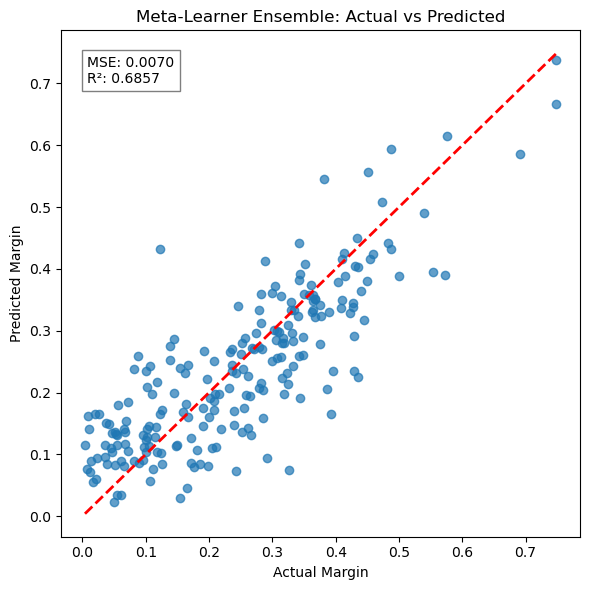

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import shap

from sklearn.metrics import mean_squared_error, r2_score

# Load pipeline results (replace with your actual path if needed)
from pipeline.pipeline import main as run_pipeline
results = run_pipeline()

# Extract models and data
models = results["models"]
x_test_scaled = results["x_test_scaled"]
y_test = results["y_test"].to_numpy()  # ensure numpy array
ensemble_preds = results["ensemble_preds"]
meta_preds = results["meta_preds"]
scaler = results["scaler"]

# Neural Network needs tensor
x_test_tensor = torch.tensor(x_test_scaled, dtype=torch.float32)

# Dictionary to hold predictions
predictions = {}

# 1️⃣ Post-Lasso
y_pred_lasso = models["Post-Lasso"].predict(x_test_scaled)
predictions["Post-Lasso"] = y_pred_lasso

# 2️⃣ Random Forest
y_pred_rf = models["Random Forest"].predict(x_test_scaled)
predictions["Random Forest"] = y_pred_rf

# 3️⃣ Neural Network
y_pred_nn = models["Neural Network"].predict(x_test_tensor).detach().numpy().squeeze()
predictions["Neural Network"] = y_pred_nn

# 4️⃣ Weighted Ensemble
predictions["Weighted Ensemble"] = ensemble_preds

# 5️⃣ Meta-Learner Ensemble
predictions["Meta-Learner Ensemble"] = meta_preds

# Plot Actual vs Predicted for all models
for name, y_pred in predictions.items():
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, y_pred, alpha=0.7)
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', lw=2)
    plt.xlabel("Actual Margin")
    plt.ylabel("Predicted Margin")
    plt.title(f"{name}: Actual vs Predicted")
    
    # Compute metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    plt.text(0.05, 0.95, f"MSE: {mse:.4f}\nR²: {r2:.4f}",
             transform=plt.gca().transAxes,
             verticalalignment='top',
             bbox=dict(facecolor='white', alpha=0.5))
    
    # Save for LaTeX
    plt.tight_layout()
    plt.savefig(f"fig_{name.replace(' ', '_')}.pdf")

print("Actual vs Predicted plots saved as PDF for LaTeX.")

Baseline (Last Margin) - MSE: 0.0141
Baseline (Last Margin) - R²: 0.3659


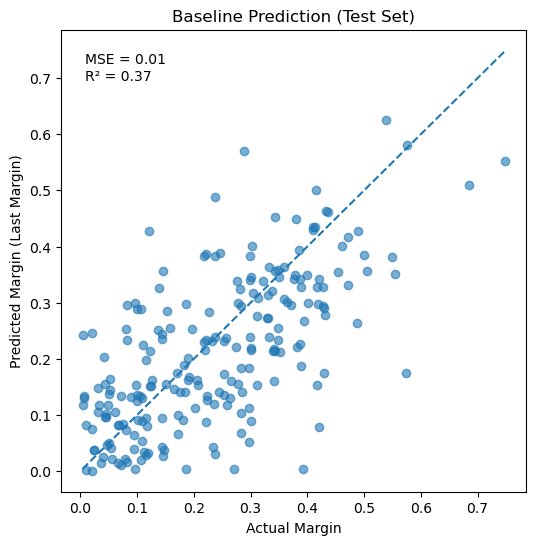

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Load raw data
df = pd.read_csv("../data/raw/constituencies_dataset.csv")

# Convert columns safely
df["margin"] = pd.to_numeric(df["margin"], errors="coerce")
df["last_margin"] = pd.to_numeric(df["last_margin"], errors="coerce")

# Drop bad rows
df = df.dropna(subset=["margin", "last_margin"])

# Recreate the same test split used in pipeline
train_df, test_df = train_test_split(
    df,
    test_size=0.1,
    random_state=42
)

# True and predicted values
y_true = test_df["margin"].to_numpy()
y_pred = test_df["last_margin"].to_numpy()

# Metrics
mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"Baseline (Last Margin) - MSE: {mse:.4f}")
print(f"Baseline (Last Margin) - R²: {r2:.4f}")

# Plot
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.6)

plt.plot(
    [y_true.min(), y_true.max()],
    [y_true.min(), y_true.max()],
    linestyle="--"
)

plt.xlabel("Actual Margin")
plt.ylabel("Predicted Margin (Last Margin)")
plt.title("Baseline Prediction (Test Set)")

plt.text(
    0.05,
    0.95,
    f"MSE = {mse:.2f}\nR² = {r2:.2f}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.show()

In [4]:
# 2️⃣ SHAP values for Random Forest
import pandas as pd

# Assuming X_test is a DataFrame (before scaling) or convert scaled data back
# Here we use the scaled version and keep column names from scaler
if hasattr(scaler, 'feature_names_in_'):
    feature_names = scaler.feature_names_in_
else:
    feature_names = [f"Var{i}" for i in range(x_test_scaled.shape[1])]

X_test_df = pd.DataFrame(x_test_scaled, columns=feature_names)

explainer = shap.TreeExplainer(models["Random Forest"])
shap_values = explainer.shap_values(X_test_df)

# Compute mean absolute SHAP for feature ranking
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top8_idx = np.argsort(mean_abs_shap)[-8:][::-1]
top8_features = X_test_df.columns[top8_idx]

# Plot SHAP values for all points for top 8 features
shap.summary_plot(
    shap_values[:, top8_idx],
    X_test_df[top8_features],
    plot_type="dot",
    show=False
)

# Save to PDF for LaTeX
plt.savefig("shap_top8_rf.pdf", bbox_inches='tight')
plt.close()

print("SHAP summary plot for top 8 features saved as PDF for LaTeX.")

/tmp/ipykernel_92183/2965755892.py:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


SHAP summary plot for top 8 features saved as PDF for LaTeX.
